<a href="https://colab.research.google.com/github/pratapsingh23/countries_state_analysis/blob/main/country_stats.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Importing required Libraries

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from math import pi

In [2]:
pd.set_option('display.float_format', lambda x: '%.2f' % x)

**Task 1: Data Loading & Initial Inspection Checklist**

In [3]:
# reading the csv file
df = pd.read_csv("/content/drive/MyDrive/country_stats.csv")

In [4]:
# Structure checking:
shape= df.shape
print(f"Rows of dataset: {shape[0]}")
print(f"Columns of dataset: {shape[1]}")

Rows of dataset: 195
Columns of dataset: 13


In [5]:
# inspect data form dataset:
df.head()

,Country name,Total in km2,Land in km2,Inland water in km2,% water,Population,% of world population,Population density,HDI,Fertility rate,Mortality rate,% of internet users in population,External debt (billions)
0,Russia,17098246.00,16376870.00,721380.00,4.20,146028325.00,1.80,8.54,0.83,1.47,13.27,95.60,299.0637
1,Canada,9984670.00,9093507.00,891163.00,8.90,41417056.00,0.50,4.15,0.94,1.33,8.17,94.40,"3,468.2119"
2,China,9596960.00,9326410.00,270550.00,2.80,1404890000.00,17.00,146.39,0.80,1.03,7.82,91.60,"2,412.0799"
3,United States,9525067.00,9147593.00,377424.00,4.00,341784857.00,4.10,35.88,0.94,1.63,8.42,94.70,"30,196.961"
4,Brazil,8510346.00,8460415.00,55352.00,0.60,214211951.00,2.60,25.17,0.79,1.59,6.90,84.50,692.6895


In [6]:
# concise summary of data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 13 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Country name                       195 non-null    object 
 1   Total in km2                       195 non-null    float64
 2   Land in km2                        194 non-null    float64
 3   Inland water in km2                194 non-null    float64
 4   % water                            194 non-null    float64
 5   Population                         194 non-null    float64
 6   % of world population              194 non-null    float64
 7   Population density                 194 non-null    float64
 8   HDI                                190 non-null    float64
 9   Fertility rate                     191 non-null    float64
 10  Mortality rate                     187 non-null    float64
 11  % of internet users in population  189 non-null    float64

In [7]:
# columns in dataset
print(df.columns)

Index(['Country name', 'Total in km2', 'Land in km2', 'Inland water in km2',
       '% water', 'Population', '% of world population', 'Population density',
       'HDI', 'Fertility rate', 'Mortality rate',
       '% of internet users in population', 'External debt (billions)'],
      dtype='object')


In [8]:
# checking null or NaN values
col_null_values = df.isnull().sum()
print(col_null_values)

# Missing values Percentage
missing_pct = (col_null_values / df.shape[0]) * 100
print("\nMissing values Percentage: ",missing_pct.sum().round(2),'%')

Country name                         0
Total in km2                         0
Land in km2                          1
Inland water in km2                  1
% water                              1
Population                           1
% of world population                1
Population density                   1
HDI                                  5
Fertility rate                       4
Mortality rate                       8
% of internet users in population    6
External debt (billions)             5
dtype: int64

Missing values Percentage:  17.44 %


**Task 2: Data Cleaning & Preprocessing**

In [9]:
# Handling missing values:

'''
We will fill missing values by MEDIAN. because, it is not affected from outliers
'''

# Land in km2
df['Land in km2'] = df['Land in km2'].fillna(df['Land in km2'].median())

# Inland water in km2
df['Inland water in km2'] = df['Inland water in km2'].fillna(df['Inland water in km2'].median())

# % water
df['% water'] = df['% water'].fillna(df['% water'].median())

# Population
df['Population'] = df['Population'].fillna(df['Population'].median())

# Population density
df['Population density'] = df['Population density'].fillna(df['Population density'].median())

# % of world population
df['% of world population'] = df['% of world population'].fillna(df['% of world population'].median())

# HDI
df['HDI'] = df['HDI'].fillna(df['HDI'].median())

# Fertility rate
df['Fertility rate'] = df['Fertility rate'].fillna(df['Fertility rate'].median())

# Mortality rate
df['Mortality rate'] = df['Mortality rate'].fillna(df['Mortality rate'].median())

# % of internet users in population
df['% of internet users in population'] = df['% of internet users in population'].fillna(df['% of internet users in population'].median())


# External debt (billions)
df['External debt (billions)'] = pd.to_numeric(df['External debt (billions)'], errors = 'coerce')
df['External debt (billions)'] = df['External debt (billions)'].fillna(df['External debt (billions)'].median())

In [10]:
# Now again checking missing values if there.
col_null_values = df.isnull().sum()
col_null_values

,0
Country name,0
Total in km2,0
Land in km2,0
Inland water in km2,0
% water,0
Population,0
% of world population,0
Population density,0
HDI,0
Fertility rate,0


In [11]:
# Checking dublicate :
df.duplicated().sum()


np.int64(0)

**Task 3: Descriptive Statistics & Aggregations**

In [12]:
# Checking summary statics:
df.describe()

,Total in km2,Land in km2,Inland water in km2,% water,Population,% of world population,Population density,HDI,Fertility rate,Mortality rate,% of internet users in population,External debt (billions)
count,195.00,195.00,195.00,195.00,195.00,195.00,195.00,195.00,195.00,195.00,195.00,195.00
mean,685093.57,661859.34,20498.04,2.56,41230406.98,0.49,316.17,0.74,2.34,7.53,71.05,89.06
std,1909727.92,1835731.74,90828.71,4.09,148773903.86,1.80,1520.98,0.15,1.10,2.82,26.57,183.14
min,0.44,0.44,0.00,0.00,882.00,0.00,2.30,0.39,0.76,1.42,0.00,0.01
25%,23082.50,22995.00,13.00,0.10,1861176.00,0.02,34.30,0.63,1.50,5.71,56.55,2.50
50%,118484.00,112325.00,1592.50,1.40,9244136.50,0.10,86.57,0.76,1.93,6.99,82.00,14.86
75%,509245.00,485845.00,8825.00,3.15,31264030.00,0.40,200.34,0.85,3.06,9.18,91.25,57.23
max,17098246.00,16376870.00,891163.00,27.80,1429404000.00,17.30,19428.50,0.97,5.84,21.70,100.00,937.31


In [13]:
# Top 5 countries by population:
pop_top5 =df.nlargest(5, 'Population')[['Country name', 'Population']].reset_index()
display(pop_top5)

,index,Country name,Population
0,6,India,1429404000.00
1,2,China,1404890000.00
2,3,United States,341784857.00
3,13,Indonesia,288315089.00
4,32,Pakistan,241499431.00


In [14]:
#Bottom 5 countries by population:
pop_bottom5 = df.nsmallest(5, 'Population')[['Country name', 'Population']].reset_index()
display(pop_bottom5)

,index,Country name,Population
0,194,Vatican City,882.00
1,191,Tuvalu,10643.00
2,192,Nauru,11680.00
3,179,Palau,16733.00
4,190,San Marino,34167.00


In [15]:
# Top 5 & Bottom 5 Countries by HDI:
hdi_top5 = df.nlargest(5, 'HDI')[['Country name', 'HDI']]
print("Top 5 Countries by HDI \n")
display(hdi_top5)

print("\n", '='*30, "\n")
hdi_bottom5 = df.nsmallest(5, 'HDI')[['Country name', 'HDI']]
print("Bottom 5 Countries by HDI \n")
display(hdi_bottom5)


Top 5 Countries by HDI 



,Country name,HDI
105,Iceland,0.97
60,Norway,0.97
131,Switzerland,0.97
129,Denmark,0.96
54,Sweden,0.96




Bottom 5 Countries by HDI 



,Country name,HDI
40,South Sudan,0.39
42,Somalia,0.40
43,Central African Republic,0.41
19,Chad,0.42
20,Niger,0.42


In [16]:
# Top 5 External Debt Countries:
exdept_top5 = df.nlargest(5, 'External debt (billions)')[['Country name', 'External debt (billions)']]
print("Top 5 Countries by External Debt \n")
display(exdept_top5)


Top 5 Countries by External Debt 



,Country name,External debt (billions)
112,Austria,937.31
12,Mexico,880.00
60,Norway,875.60
106,South Korea,774.39
6,India,762.77


**Task 4: Matplotlib Visualizations (More Specific)**

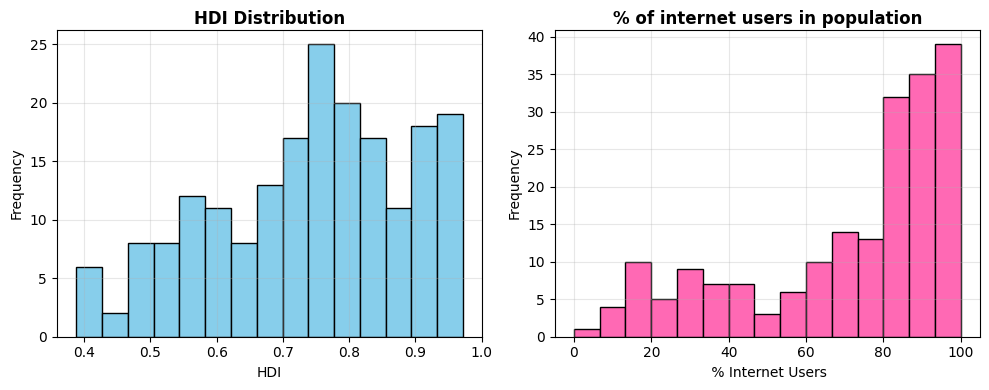

In [17]:
# HDI and  % of internet users in population

fig, ax = plt.subplots(1,2, figsize = (10,4))

# HDI histogram:
ax[0].hist(df['HDI'], bins = 15, color = 'skyblue', edgecolor = 'black')
ax[0].set_title('HDI Distribution', fontweight = 'bold', pad = 4)
ax[0].set_xlabel('HDI')
ax[0].set_ylabel("Frequency")
ax[0].grid(alpha = 0.3)


# % of internet users in population histogram:
ax[1].hist(df['% of internet users in population'], bins = 15, color = 'hotpink', edgecolor = 'black')
ax[1].set_title('% of internet users in population', fontweight = 'bold', pad = 4)
ax[1].set_xlabel(' % Internet Users')
ax[1].set_ylabel("Frequency")
ax[1].grid(alpha = 0.3)


plt.tight_layout()
plt.savefig('hdi_and_pct_of_internet_user.png')
plt.show()


Correlation: 0.24


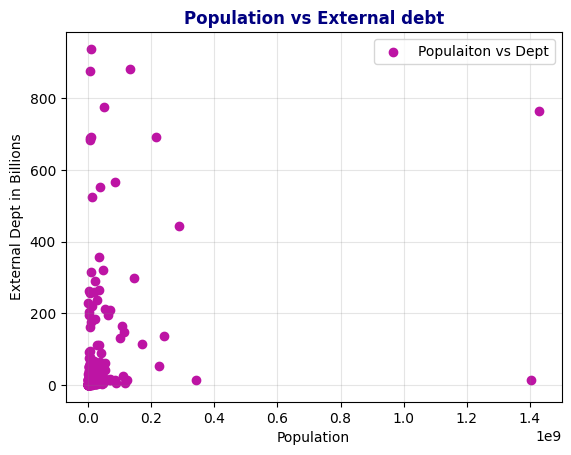

In [30]:
# Population vs External debt (billions)
corr = df['Population'].corr(df['External debt (billions)'])
print(f"Correlation: {corr.round(2)}")
plt.scatter(df['Population'], df['External debt (billions)'], color = '#BD14A4', label = 'Populaiton vs Dept')
plt.title("Population vs External debt", fontweight = 'bold', color = 'navy')
plt.xlabel("Population")
plt.ylabel("External Dept in Billions")
plt.grid(alpha = 0.2, color = 'grey')
plt.legend()
plt.savefig('population_debt.png')
plt.show()


**Task 5: Specific analysis of one Country - India**


--- India's all Ranks ---
 Total in km2  Land in km2  Inland water in km2  % water  Population  % of world population  Population density  HDI  Fertility rate  Mortality rate  % of internet users in population  External debt (billions) Country name
            7            7                    4       11           1                      1                  19  133              95              36                                128                         5        India


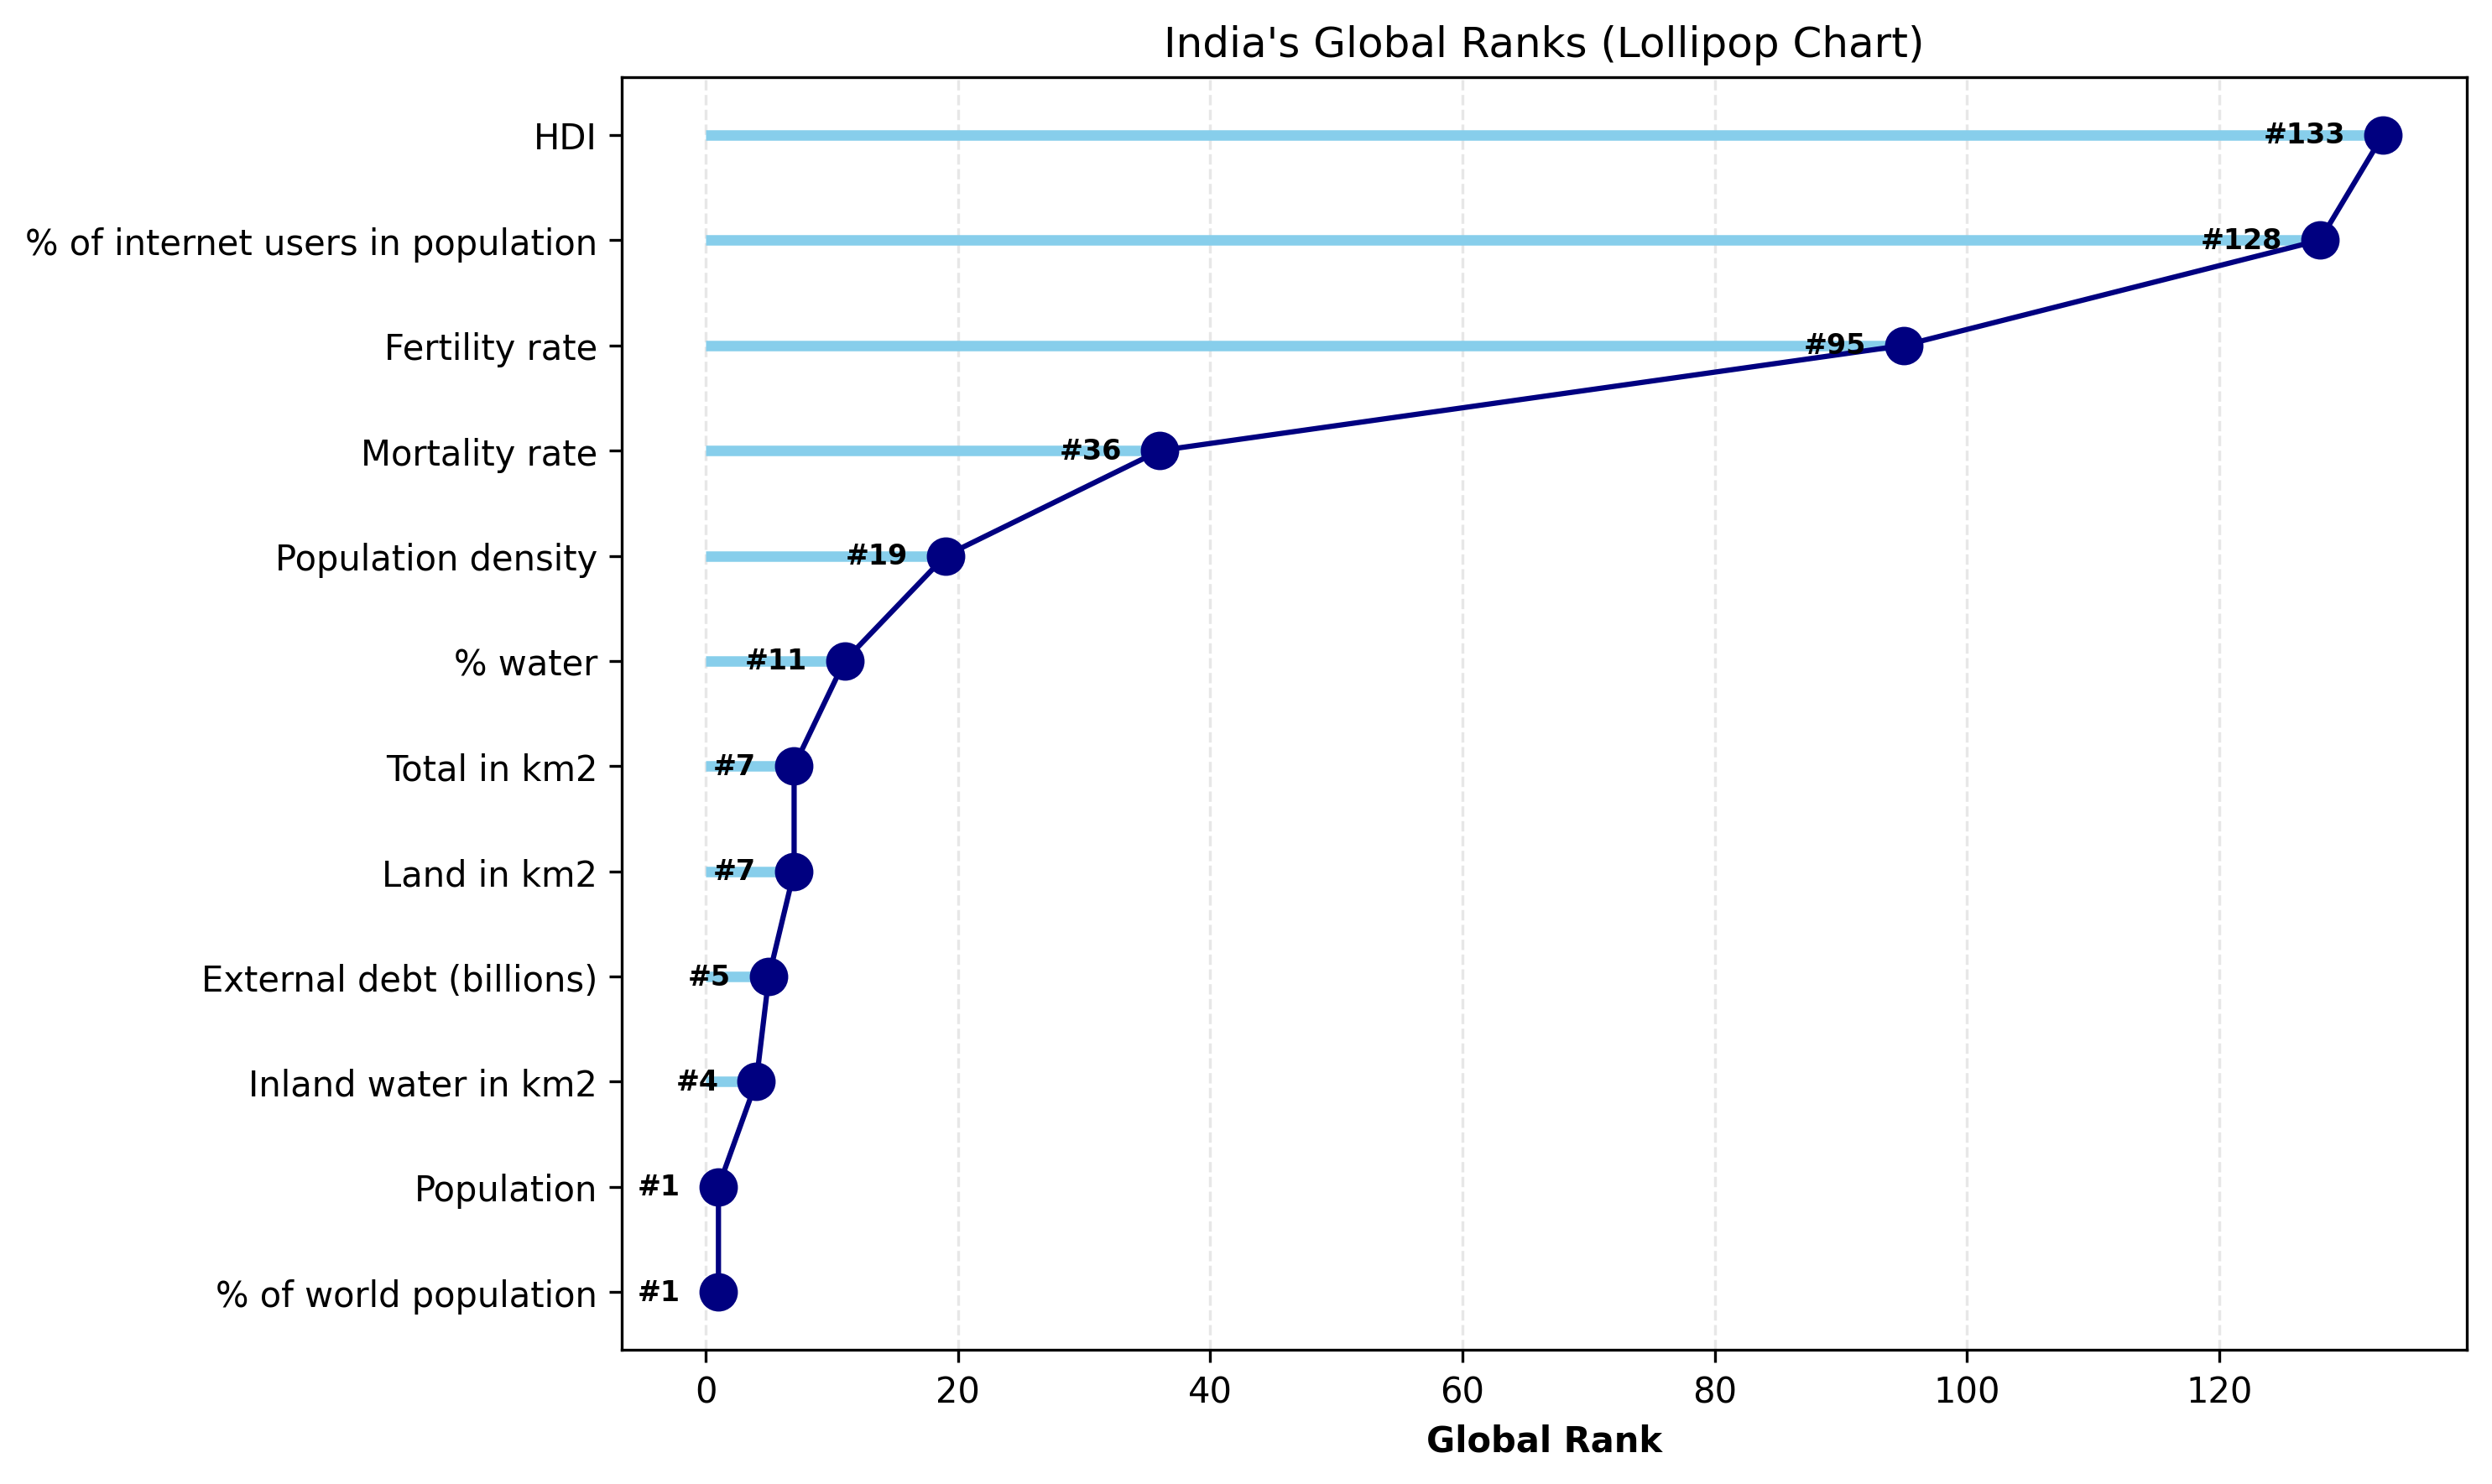

In [25]:
# global rank checking in various categories:
target_country = 'India'
numeric_cols = df.select_dtypes(include =['number']).columns

ranks_df = df[numeric_cols].rank(ascending= False, method = 'min').astype(int)

ranks_df['Country name'] = df['Country name']

ind_ranks = ranks_df[ranks_df['Country name'] == target_country]

final_ind_ranks = ind_ranks.to_string(index = False)
print(f"\n--- {target_country}'s all Ranks ---")
print(final_ind_ranks)



# Visulization:

ind_ranks_long = ind_ranks.melt(id_vars=['Country name'], var_name = 'metric', value_name = 'rank')

ind_ranks_long = ind_ranks_long.sort_values(
    'rank', ascending=True
)

plt.figure(figsize = (10,6), dpi = 300)

# creating a stick
plt.hlines(y = ind_ranks_long['metric'], xmin = 0, xmax = ind_ranks_long['rank'], color = 'skyblue', lw=3)

# creating a candy
plt.plot(ind_ranks_long['rank'], ind_ranks_long['metric'], marker = 'o', markersize = 10, color = 'navy' )


plt.xlabel("Global Rank", fontweight ='semibold')
plt.title("India's Global Ranks (Lollipop Chart)")

# texts label on dots:

for i, rank in enumerate(ind_ranks_long['rank']):
  plt.text(rank - 3, i, f"#{rank}", va = "center", ha = "right", color = 'black', fontweight = 'bold', fontsize = 8)

plt.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('india_rank_at_global.png')
plt.show()

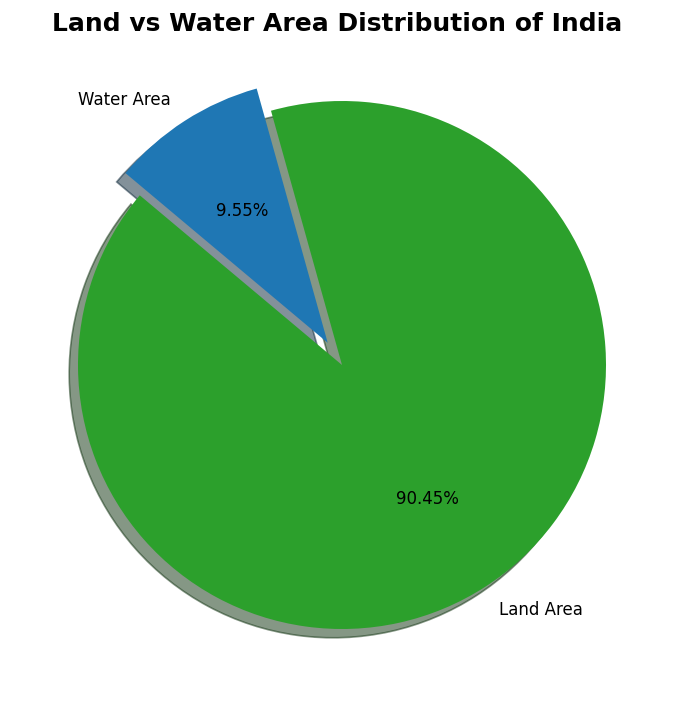

In [26]:
# Land vs Water Area Distribution
land_area = df[df['Country name'] == target_country]['Land in km2'].values[0]

water_area = df[df['Country name'] == target_country]['Inland water in km2'].values[0]

total_area = land_area + water_area

ind_land_pct = (land_area / total_area) * 100
ind_water_pct = (water_area / total_area) * 100


# visualize:

# pie chart data:
areas = [ind_land_pct, ind_water_pct]
labels = ["Land Area", "Water Area"]
colors =  ['#2ca02c', '#1f77b4']
plt.figure(figsize =(6,6), dpi= 120)

plt.pie(
    areas,
    colors = colors,
    labels = labels,
    autopct = '%1.2f%%',
    startangle = 140,
    explode = (0,0.1),
    shadow = True

)

plt.title("Land vs Water Area Distribution of India ", fontweight = "bold", fontsize = 15, pad = 3)
plt.tight_layout()
plt.savefig('land_water_area.png')
plt.show()

BRICS population



,Country name,Population
6,India,1429404000.00
2,China,1404890000.00
13,Indonesia,288315089.00
4,Brazil,214211951.00
0,Russia,146028325.00
25,Ethiopia,111652998.00
28,Egypt,108613296.00
16,Iran,87134000.00
23,South Africa,63522380.00
11,Saudi Arabia,35300280.00



BRICS population density



,Country name,Population density
6,India,434.83
13,Indonesia,151.38
2,China,146.39
113,United Arab Emirates,135.10
28,Egypt,108.46
25,Ethiopia,101.11
16,Iran,52.87
23,South Africa,52.11
4,Brazil,25.17
11,Saudi Arabia,16.42


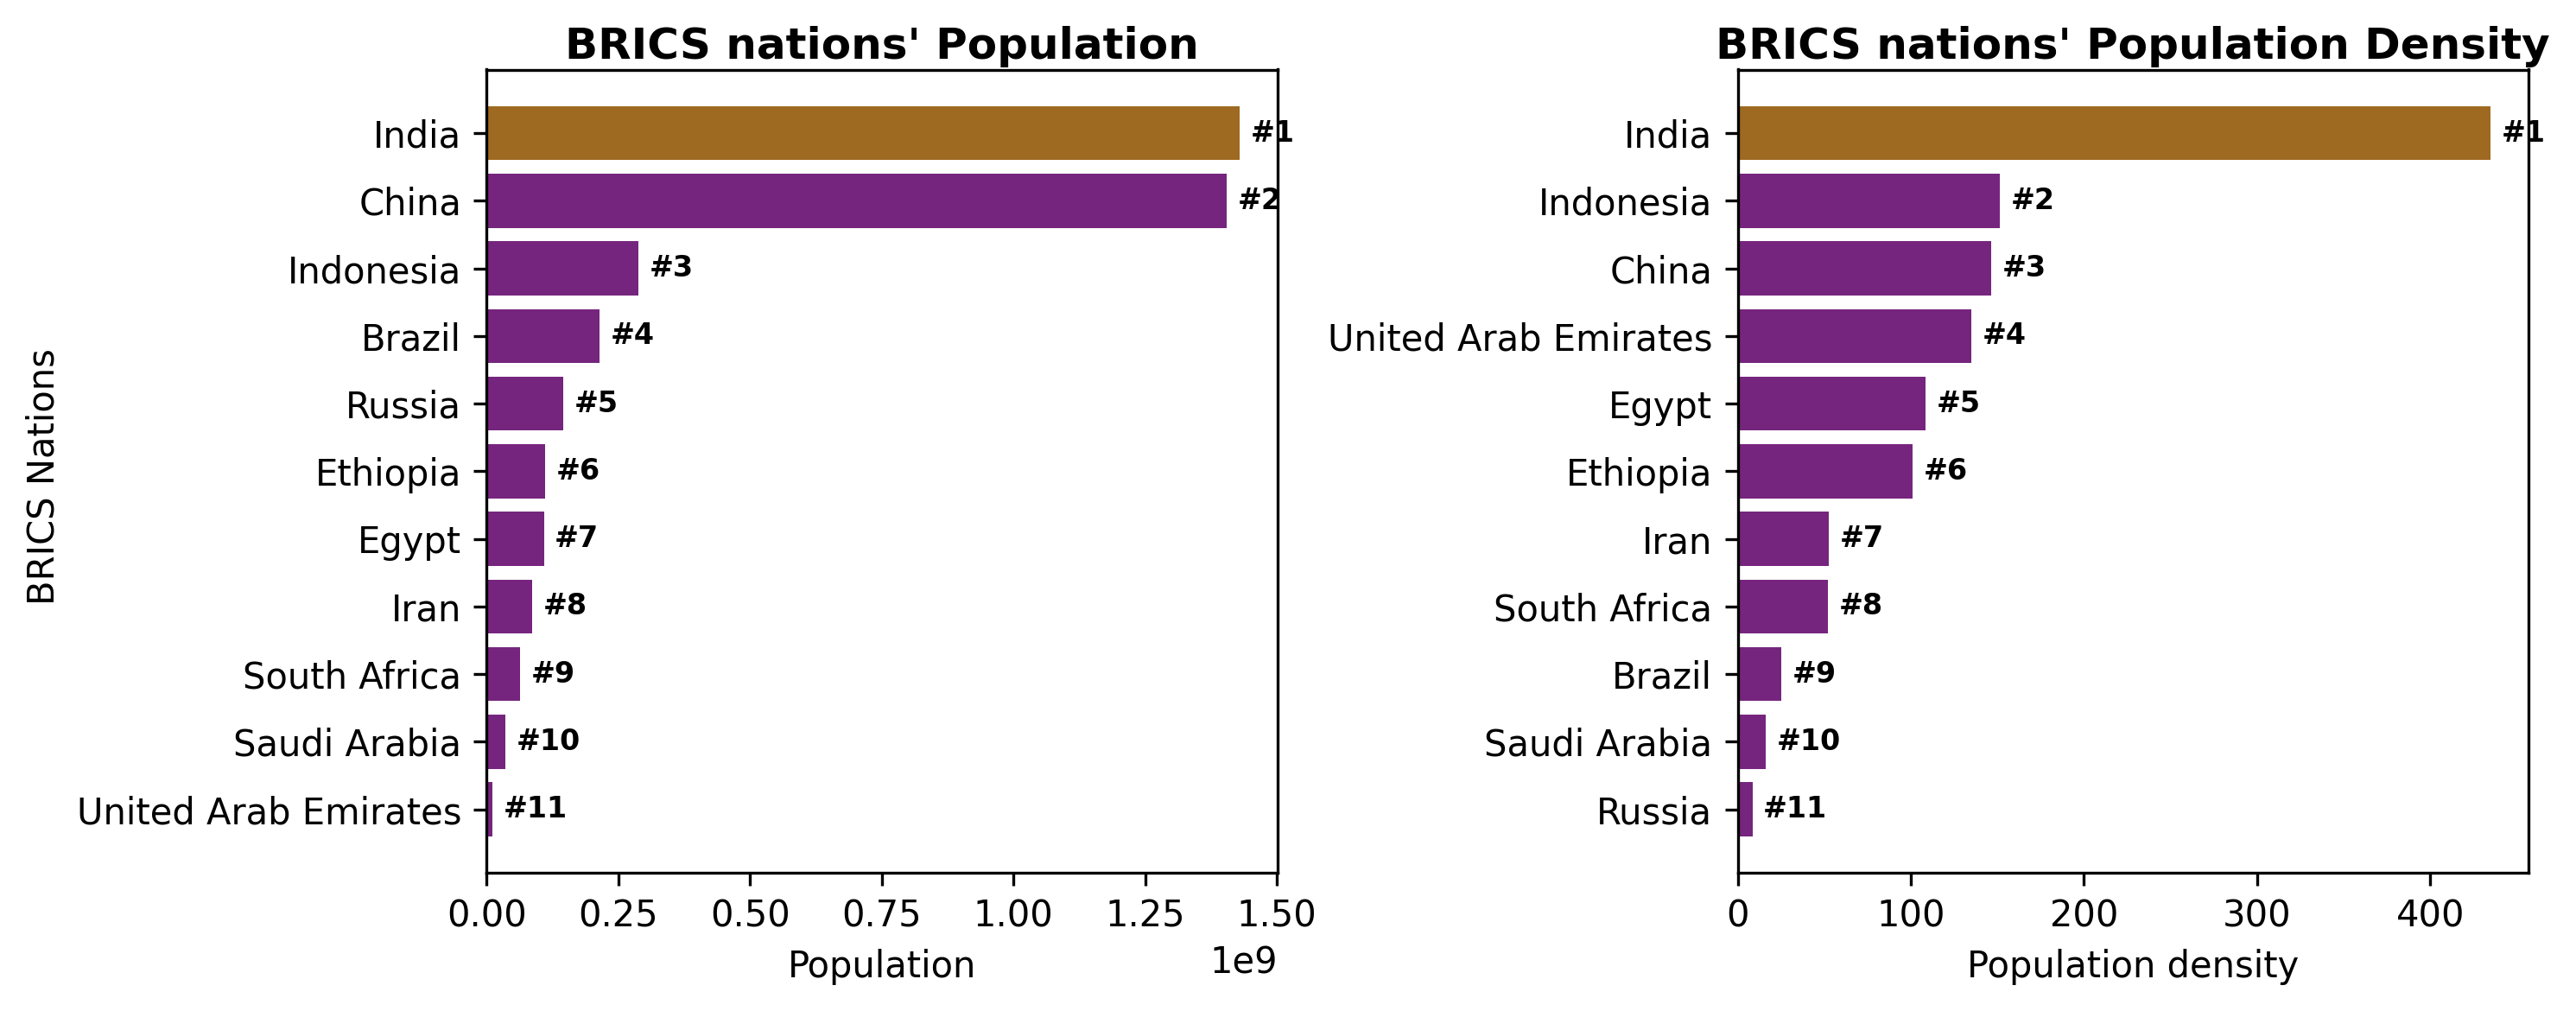

In [27]:
# Population & Density Comparison in Asia/BRICS

# BRICS population
brics_nation = [
    'Brazil', 'Russia', 'India', 'China', 'South Africa', 'Egypt', 'Ethiopia', 'Iran', 'United Arab Emirates', 'Indonesia', 'Saudi Arabia'
]

brics_population = df[df['Country name'].isin(brics_nation)][['Country name','Population']]

brics_population = brics_population.sort_values(by = 'Population', ascending= True)

print("BRICS population\n")
display(brics_population.sort_values(by = 'Population', ascending = False))


# BRICS Population Density
brics_density = df[df['Country name'].isin(brics_nation)][['Country name', 'Population density']]
brics_density = brics_density.sort_values(by = 'Population density', ascending= True)

print("\nBRICS population density\n")
display(brics_density.sort_values(by = 'Population density', ascending = False))
print('\n')


#  visualize:
fig, ax = plt.subplots(1,2, figsize = (10,4), dpi = 300)

# BRICS population - Bar chart:
bars0 = ax[0].barh(
    brics_population['Country name'],
    brics_population['Population'],
    color = ['#9E6920' if nation == 'India' else '#76257E' for nation in brics_population['Country name']],
)
ax[0].set_title("BRICS nations' Population"  ,fontweight = 'bold', pad= 3)
ax[0].set_xlabel("Population")
ax[0].set_ylabel("BRICS Nations ")

# Ranks labels:
pop_ranks = list(range(len(brics_population), 0, -1))
pop_labels = [f'#{r}' for r in pop_ranks]
ax[0].bar_label(bars0, labels = pop_labels, padding =3, fontweight = 'bold', fontsize = 8)


# # BRICS Population Density - Bar chart:
bars1 = ax[1].barh(
    brics_density['Country name'],
    brics_density['Population density'],
    color = ['#9E6920' if nation == 'India' else '#76257E' for nation in brics_density['Country name']],
   )
ax[1].set_title("BRICS nations' Population Density", fontweight = 'bold', pad= 3)
ax[1].set_xlabel("Population density")
# ax[1].set_ylabel("BRICS Nations ")

# ranks labels:
popd_ranks = list(range(len(brics_density), 0, -1))
popd_labels = [f'#{r}' for r in popd_ranks]
ax[1].bar_label(bars1, labels = popd_labels, padding = 3, fontweight = 'bold', fontsize = 8 )

plt.tight_layout()
plt.savefig('brics_nations.png')
plt.show()





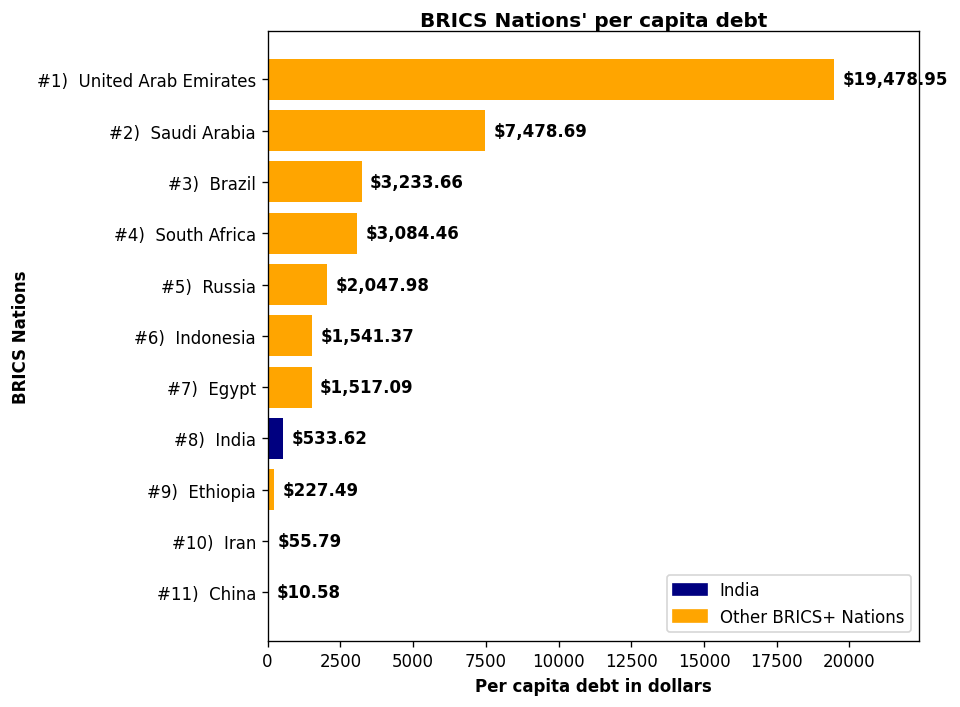

In [28]:
#  Per Capita External Debt

def get_country_row(country):
  row = df[df['Country name'] == country]
  return row.iloc[0]

# Population:
def country_population(country):
  return get_country_row(country)['Population']

# External Debt:
def country_external_debt(country):
  return get_country_row(country)['External debt (billions)']

# per capita debt :
def capita_debt(country):
  debt_billions = country_external_debt(country)
  population = country_population(country)

  debt_dollars = debt_billions * 1e9

  per_capita = debt_dollars / population


  return per_capita.round(2)

brics_nation = [
    'Brazil', 'Russia', 'India', 'China', 'South Africa', 'Egypt', 'Ethiopia', 'Iran', 'United Arab Emirates', 'Indonesia', 'Saudi Arabia'
]

debts = [capita_debt(c) for c in brics_nation]

per_capita_df = pd.DataFrame({
    'brics_nation': brics_nation,
    'debts': debts
})
per_capita_df = per_capita_df.sort_values(by = 'debts', ascending= True)

# Finding Rank:
per_capita_df['rank'] = per_capita_df['debts'].rank(ascending = False, method = 'min').astype(int)

per_capita_df['y_label'] = '#' + per_capita_df['rank'].astype(str) + ')'+'  ' + per_capita_df['brics_nation']

per_capita_df['formatted_text'] = per_capita_df['debts'].map('${:,.2f}'.format)


# visualisation:

colors = np.where(per_capita_df['brics_nation'] == 'India', 'navy', 'orange')

plt.figure(figsize = (8,6), dpi = 120)
bars = plt.barh(
    per_capita_df['y_label'],
    per_capita_df['debts'],
    color = colors,
)
plt.bar_label(bars, labels = per_capita_df['formatted_text'],fmt = '$%g', padding =5, fontweight = 'bold')

plt.xlim(0, max(per_capita_df['debts']) * 1.15)

plt.xlabel("Per capita debt in dollars",  fontweight = 'semibold')

plt.ylabel("BRICS Nations", fontweight = 'semibold')
plt.title("BRICS Nations' per capita debt", fontweight = 'bold', pad =3)

# custom legend:
india_patch = mpatches.Patch(color = 'navy', label = 'India')
brics_patch = mpatches.Patch(color = 'orange', label = 'Other BRICS+ Nations')
# passing in legend:
plt.legend(
    handles = [india_patch, brics_patch],
    loc = 'lower right',
    frameon = True
)

plt.tight_layout()
plt.savefig('brics_nations_per_capita_debt.png')
plt.show()

